In [ ]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import numpy              as np
import pandas             as pd
import seaborn            as sbn
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections           import Counter
from sklearn.cluster       import DBSCAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from Customer_dataset import data
processed_data = data.copy()

Tiền xử lý dữ liệu

In [ ]:

print(processed_data.head())
print(processed_data.shape)

   Age  Income_Level  Gender_Male
0   23         70541            0
1   26         54168            1
2   29         73899            0
3   20         63381            1
4   25         38794            0
(1000, 3)


In [5]:
## Quan sát sơ bộ dữ liệu
print('Shape:', processed_data.shape)
print()
print(processed_data.dtypes)

Shape: (1000, 3)

Age             int64
Income_Level    int64
Gender_Male     int64
dtype: object


In [25]:
## Quan sát phân phối một số thuộc tính quan trọng
print('Gender:')
print(processed_data.groupby('Gender_Male').Age.count())
data_model=processed_data.copy()

Gender:
Gender_Male
0    479
1    521
Name: Age, dtype: int64


In [12]:
##------------------------------------------------------------------------------
## Chuẩn hóa dữ liệu trước khi áp dụng DBSCAN
##------------------------------------------------------------------------------
## DBSCAN dựa trên khoảng cách (eps) nên CẦN chuẩn hóa để các thuộc tính
## có cùng đơn vị đo lường, tránh thuộc tính có giá trị lớn chi phối kết quả.
##------------------------------------------------------------------------------
scaler      = StandardScaler()
data_scaled = scaler.fit_transform(data_model)
print('Dữ liệu sau chuẩn hóa (5 dòng đầu):')
print(data_scaled[:5])

Dữ liệu sau chuẩn hóa (5 dòng đầu):
[[-1.44282017 -0.35110979 -1.04292026]
 [-1.24477568 -0.79025475  0.95884608]
 [-1.04673118 -0.2610439  -1.04292026]
 [-1.64086467 -0.54315021  0.95884608]
 [-1.31079051 -1.20260523 -1.04292026]]


In [13]:
##------------------------------------------------------------------------------
## Xây dựng mô hình DBSCAN
##------------------------------------------------------------------------------
## eps        : bán kính lân cận (neighborhood radius)
## min_samples: số điểm tối thiểu trong lân cận để tạo thành core point
##
## Nhãn cluster = -1 → điểm NHIỄU (noise/outlier), không thuộc cụm nào
##------------------------------------------------------------------------------
model = DBSCAN(eps=1.5, min_samples=10)
model.fit(data_scaled)  # xây dựng mô hình

,eps,1.5
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [14]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model, '../customer_clustering/Output/DBSCAN.mdl')

['../customer_clustering/Output/DBSCAN.mdl']

In [15]:
## Khai thác mô hình đã được xây dựng
model = jlb.load('../customer_clustering/Output/DBSCAN.mdl')

In [16]:
## Kết quả gom cụm khách hàng
data['cluster'] = model.labels_
print(data[['Age', 'Income_Level', 'cluster']].head(10))

n_clusters = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
n_noise    = list(model.labels_).count(-1)

print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nKích thước các clusters (bao gồm noise = -1):', Counter(model.labels_))

   Age  Income_Level  cluster
0   23         70541        0
1   26         54168        1
2   29         73899        0
3   20         63381        1
4   25         38794        0
5   41         87188        0
6   55         94891        1
7   35         61003        1
8   43        116249        0
9   32         49083        0

Số clusters tìm được  : 2
Số điểm nhiễu (noise): 0

Kích thước các clusters (bao gồm noise = -1): Counter({np.int64(1): 521, np.int64(0): 479})


Biểu diễn trực quan

In [17]:
## Lấy 2 thuộc tính số để vẽ: Income Level và Age
data2d = data[['Age', 'Income_Level']].copy()

In [19]:

scaler      = StandardScaler()
data2d_scaled = scaler.fit_transform(data2d)

In [22]:
model2d = DBSCAN(eps=0.2, min_samples=10)
model2d.fit(data2d_scaled)

data2d['cluster'] = model2d.labels_
print(data2d.head(10))

n_clusters = len(set(model2d.labels_)) - (1 if -1 in model2d.labels_ else 0)
n_noise    = list(model2d.labels_).count(-1)
print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nClusters lớn nhất:', Counter(model2d.labels_).most_common(1))

   Age  Income_Level  cluster
0   23         70541        0
1   26         54168        0
2   29         73899        0
3   20         63381        0
4   25         38794        0
5   41         87188        0
6   55         94891        0
7   35         61003        0
8   43        116249        0
9   32         49083        0

Số clusters tìm được  : 9
Số điểm nhiễu (noise): 72

Clusters lớn nhất: [(np.int64(0), 644)]


In [23]:
for eps in [0.2, 0.3, 0.5, 0.8, 1.0]:
    m          = DBSCAN(eps = eps, min_samples = 10).fit(data2d_scaled)
    n_clusters = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
    n_noise    = list(m.labels_).count(-1)
    print(f'eps={eps} → clusters: {n_clusters}, noise: {n_noise}')

eps=0.2 → clusters: 9, noise: 72
eps=0.3 → clusters: 1, noise: 0
eps=0.5 → clusters: 1, noise: 0
eps=0.8 → clusters: 1, noise: 0
eps=1.0 → clusters: 1, noise: 0


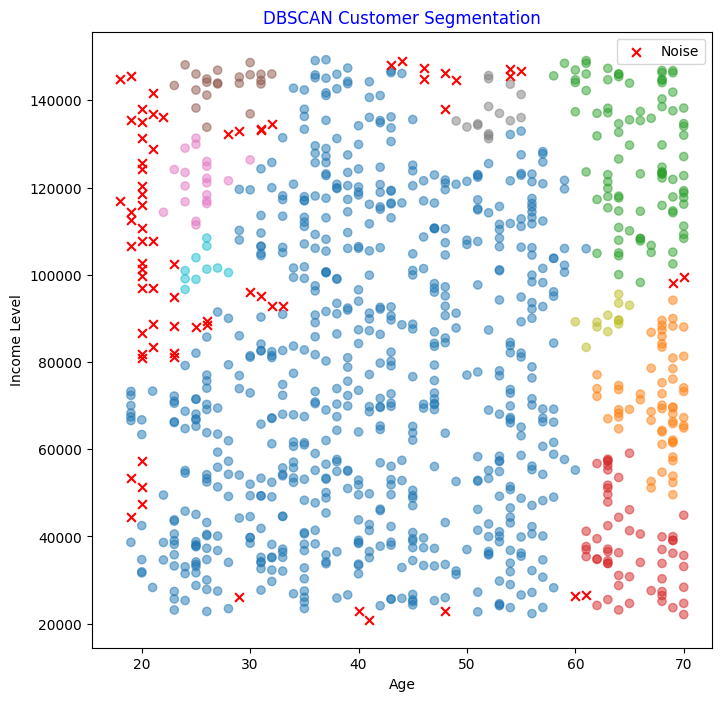

In [24]:
noise    = data2d[data2d.cluster == -1]
clusters = data2d[data2d.cluster != -1]

plt.figure(figsize=(8, 8))
plt.scatter(clusters.Age, clusters['Income_Level'], c=clusters.cluster, alpha=0.5, cmap='tab10')
plt.scatter(noise.Age, noise['Income_Level'], c='red', marker='x', s=40, label='Noise', zorder=5)
plt.xlabel('Age')
plt.ylabel('Income Level')
plt.title('DBSCAN Customer Segmentation', color='blue')
plt.legend()
plt.show()